#### CNN을 이용한 fingers image 분류

In [2]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
# train, vaild, test로 나누기
train_images = glob.glob("../Data/fingers/train/*.png")
test_images = glob.glob("../Data/fingers/test/*.png")

In [5]:
# file name 확인
train_images[:5]

['../Data/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [6]:
# 갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [7]:
# train data와 test data 만들기 : 128*128 -> 32*32

train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

In [8]:
# Target Data확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


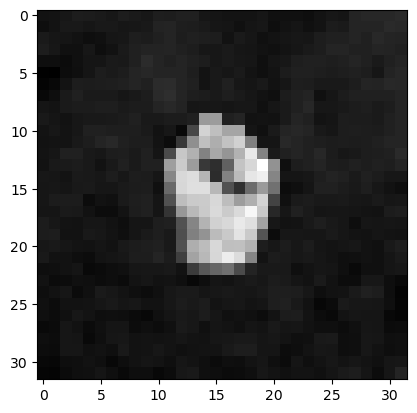

In [9]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

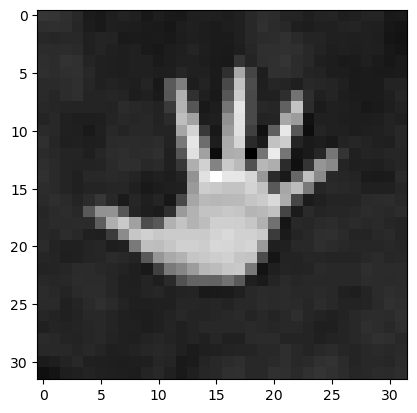

In [11]:
# test의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

#### numpy 배열로 변경

In [13]:
import numpy as np

In [14]:
# train Data 만들기(18000 * 32 * 32)
tempData = np.zeros(
    18000 * 32 * 32,
    dtype=np.int32
).reshape(18000, 32, 32)


i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

train_input = tempData.copy()

In [15]:
# test Data 만들기(3600 * 32 * 32)
tempData = np.zeros(
    3600 * 32 * 32,
    dtype=np.int32
).reshape(3600, 32, 32)


i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

test_input = tempData.copy()

In [16]:
# 배열크기 확인
print(train_input.shape)
print(test_input.shape)

(18000, 32, 32)
(3600, 32, 32)


In [17]:
train_input[0]

array([[51, 52, 55, ..., 66, 66, 68],
       [48, 52, 56, ..., 64, 68, 67],
       [57, 54, 53, ..., 67, 65, 63],
       ...,
       [47, 46, 54, ..., 51, 48, 50],
       [44, 43, 48, ..., 50, 54, 55],
       [42, 41, 46, ..., 47, 54, 64]], shape=(32, 32), dtype=int32)

----
#### target를 숫자로 변경하기

In [18]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11
}

In [19]:
# Train target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [20]:
# Test target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [21]:
train_target[:5]

[6, 6, 8, 6, 11]

In [22]:
test_target[:5]

[11, 11, 3, 11, 11]

In [23]:
# Target도 numpy배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

print(train_target[:5])
print(test_target[:5])

[ 6  6  8  6 11]
[11 11  3 11 11]


#### train valid test 구성

In [24]:
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [25]:
train_scaled = (train_input / 255.0)
test_scaled = (test_input / 255.0)

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )


In [27]:
# 크기 확인
print(train_scaled.shape)
print(val_scaled.shape)
print(test_scaled.shape)
print(train_target.shape)
print(val_target.shape)
print(test_target.shape)

(14400, 32, 32)
(3600, 32, 32)
(3600, 32, 32)
(14400,)
(3600,)
(3600,)


#### CNN 만들기

In [28]:
model = keras.Sequential()

In [29]:
model.add(
    keras.layers.Conv2D(
        32, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same', #valid
        input_shape=(32, 32, 1)
    )
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링층

In [30]:
# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### 두번째 합성곱층

In [31]:
model.add(
    keras.layers.Conv2D(
        64, # Filter의 갯수 (32, 64, 128, 256...)
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding='same' #valid
    )
)

# Pooling
model.add(
    keras.layers.MaxPool2D(2) # 2*2 max pooling
)

#### Dense 층

In [32]:
# 입력층
model.add(
    keras.layers.Flatten()
)

#은닉층
model.add(
    keras.layers.Dense(
        100,
        activation='relu'
    )
)

# Dropout 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        12,
        activation='softmax'
    )
)

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,728 (1.64 MB)

 Trainable params: 429,728 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile

In [34]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_fingers.keras")

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

In [35]:
history = model.fit(
    train_scaled,
    train_target,
    epochs = 20,
    validation_data=(val_scaled, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8128 - loss: 0.5745 - val_accuracy: 0.9919 - val_loss: 0.0276
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9758 - loss: 0.0762 - val_accuracy: 0.9997 - val_loss: 0.0040
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9860 - loss: 0.0424 - val_accuracy: 0.9981 - val_loss: 0.0050
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9917 - loss: 0.0257 - val_accuracy: 1.0000 - val_loss: 2.8865e-04
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9926 - loss: 0.0241 - val_accuracy: 1.0000 - val_loss: 8.1821e-04
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9926 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 1.5218e-04
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9951 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 9.3562e-05
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9954 - loss: 0

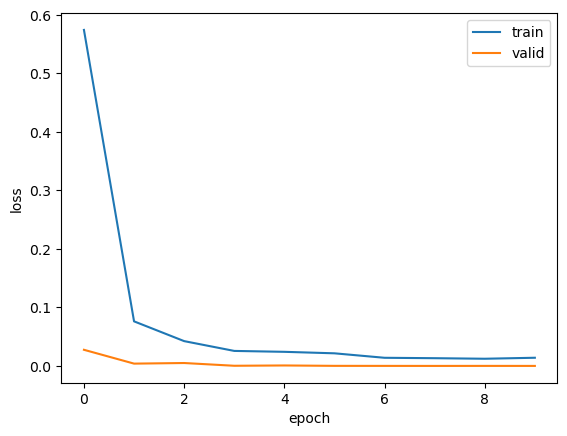

In [43]:
# History의 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

#### 평가와 예측

In [36]:
model.evaluate(train_scaled, train_target)
model.evaluate(val_scaled, val_target)
model.evaluate(test_scaled, test_target)

450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 2.0544e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.8479e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 7.2956e-05


[7.295646355487406e-05, 1.0]

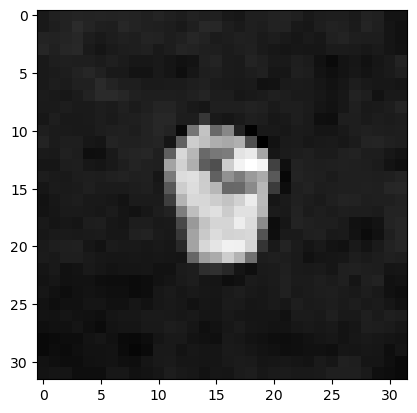

In [37]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(32, 32),
    cmap='gray'
)
plt.show()

In [39]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[7.6574892e-08, 1.3185857e-11, 9.7007176e-18, 7.2612974e-16,
        3.6153564e-15, 8.4226012e-18, 9.9999976e-01, 8.3019692e-08,
        2.4394233e-15, 4.4984524e-17, 5.5002075e-12, 4.0187504e-13]],
      dtype=float32)

In [40]:
# 글자로 변경하기
import numpy as np
classes = ['오른손0', '오른손1', '오른손2', '오른손3', '오른손4', '오른손5', '왼손0', '왼손1', '왼손2', '왼손3', '왼손4', '왼손5']
len(classes)

12

In [41]:
classes[np.argmax(pred)]

'왼손0'